# Predicción de Churn en Telco — 01 · Análisis Exploratorio

**Caso de negocio:** una empresa de telecomunicaciones quiere identificar qué clientes tienen alta
probabilidad de dar de baja el servicio (*churn*) durante el próximo mes, para que el equipo de
retención pueda actuar de forma proactiva (ofertas, cambio de plan, contacto directo).

- **Unidad observacional:** cliente activo.
- **Variable respuesta:** `Churn` (Yes/No — el cliente se dio de baja en el último mes).
- **Fuente:** IBM Telco Customer Churn (dataset público, disponible en Kaggle).
- **En producción:** scoring mensual de la cartera de clientes activos; el equipo de retención
  contacta al segmento de mayor riesgo según su capacidad operativa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette=["#4C72B0", "#C44E52"])
plt.rcParams["figure.dpi"] = 110

SEED = 42

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Observaciones: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Observaciones: 7,043 | Columnas: 21


## 1. Estructura del dataset

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "nulos": df.isna().sum(),
    "ejemplos": [", ".join(map(str, df[c].unique()[:4])) for c in df.columns],
})
resumen

,tipo,n_unicos,nulos,ejemplos
customerID,object,7043,0,"7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW"
gender,object,2,0,"Female, Male"
SeniorCitizen,int64,2,0,"0, 1"
Partner,object,2,0,"Yes, No"
Dependents,object,2,0,"No, Yes"
tenure,int64,73,0,"1, 34, 2, 45"
PhoneService,object,2,0,"No, Yes"
MultipleLines,object,3,0,"No phone service, No, Yes"
InternetService,object,3,0,"DSL, Fiber optic, No"
OnlineSecurity,object,3,0,"No, Yes, No internet service"


**Observaciones sobre la estructura:**
- `customerID` es identificador, no se usa como feature.
- `SeniorCitizen` viene como 0/1 numérico, a diferencia del resto de las binarias (Yes/No).
- `TotalCharges` figura como `object` (texto) cuando debería ser numérica → hay que revisarla.
- Varias categóricas de servicios tienen un tercer nivel redundante
  (`No internet service` / `No phone service`).

## 2. Limpieza: `TotalCharges`

In [4]:
# TotalCharges como texto: convertir a numerico y ver que falla
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
faltantes = df[df["TotalCharges"].isna()]
print(f"Valores no convertibles: {len(faltantes)}")
faltantes[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Valores no convertibles: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


Los 11 registros con `TotalCharges` vacío son todos clientes con `tenure = 0`
(clientes nuevos que todavía no facturaron un mes completo). Ninguno es churner.
La imputación natural es `TotalCharges = 0`.

In [5]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
assert df["customerID"].is_unique, "hay clientes duplicados"
print("Sin duplicados de cliente. Nulos restantes:", int(df.isna().sum().sum()))

Sin duplicados de cliente. Nulos restantes: 0


## 3. Balance de clases

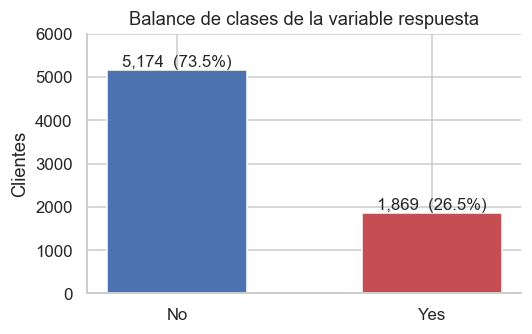

Tasa de churn (prevalencia): 0.265


In [6]:
df["_churn"] = (df["Churn"] == "Yes").astype(int)
tasa_global = df["_churn"].mean()

fig, ax = plt.subplots(figsize=(5, 3.2))
conteo = df["Churn"].value_counts()
bars = ax.bar(conteo.index, conteo.values, color=["#4C72B0", "#C44E52"], width=0.55)
for b, v in zip(bars, conteo.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 60, f"{v:,}  ({v / len(df):.1%})",
            ha="center", fontsize=11)
ax.set_title("Balance de clases de la variable respuesta")
ax.set_ylabel("Clientes")
ax.set_ylim(0, 6000)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Tasa de churn (prevalencia): {tasa_global:.3f}")

Dataset **desbalanceado** (~26,5% de churners). Consecuencias para el modelado:
- *Accuracy* no sirve como métrica (predecir siempre "No" ya da ~73%).
- Se usará **PR-AUC** (average precision) para comparar modelos — su baseline es la
  prevalencia (~0,265) — y **F2** para elegir el umbral operativo, priorizando *recall*:
  perder un cliente sin intentar retenerlo cuesta más que una llamada de más.

## 4. Variables numéricas

In [7]:
numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numericas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80


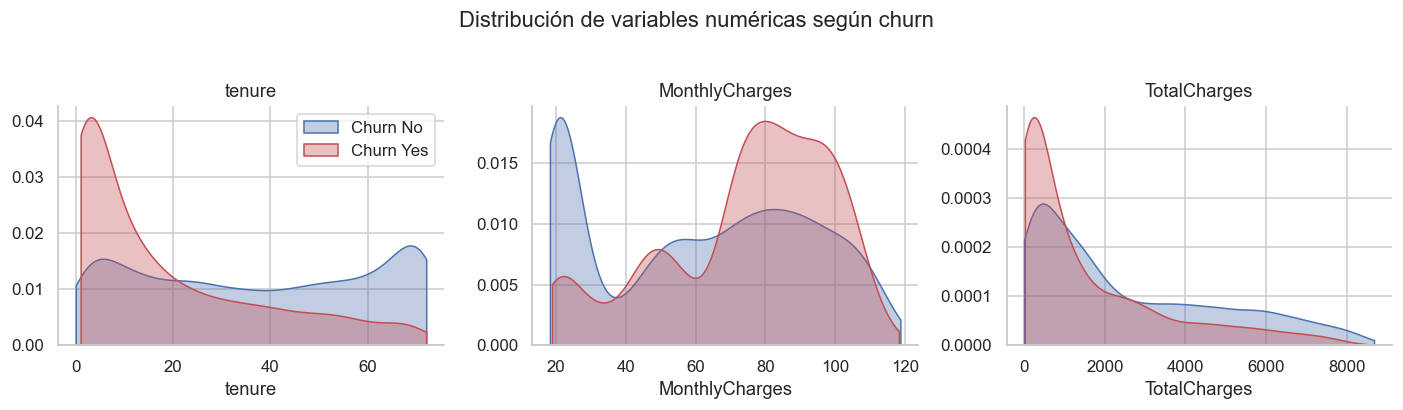

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, numericas):
    for valor, color in [("No", "#4C72B0"), ("Yes", "#C44E52")]:
        sns.kdeplot(df.loc[df["Churn"] == valor, col], ax=ax, label=f"Churn {valor}",
                    fill=True, alpha=0.35, color=color, cut=0)
    ax.set_title(col)
    ax.set_ylabel("")
axes[0].legend()
fig.suptitle("Distribución de variables numéricas según churn", y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

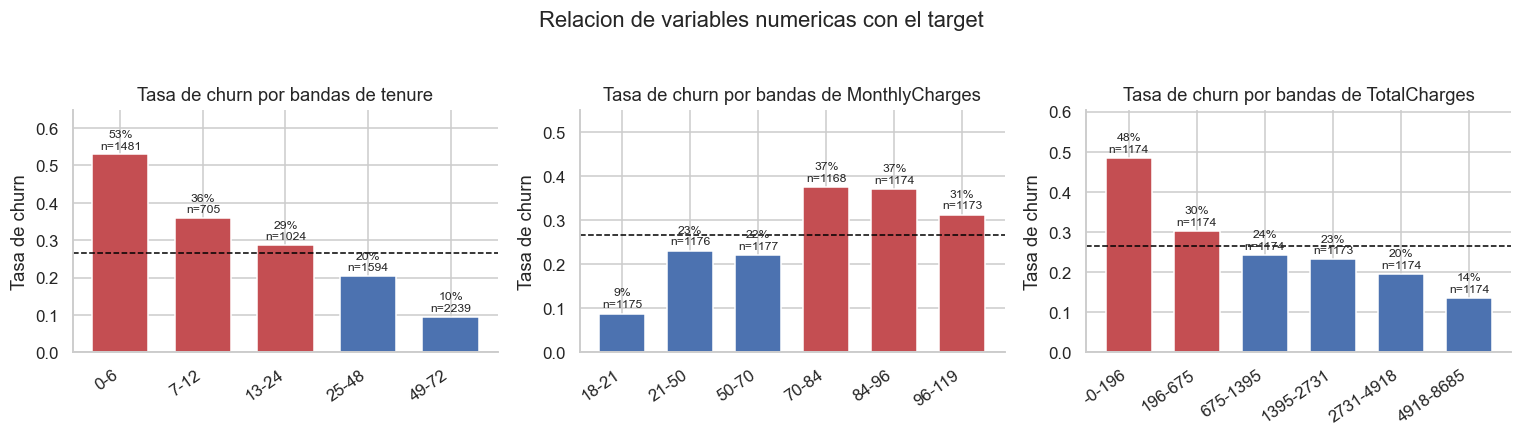

In [9]:
def etiqueta_intervalo(valor):
    if hasattr(valor, "left") and hasattr(valor, "right"):
        return f"{valor.left:.0f}-{valor.right:.0f}"
    return str(valor)

numeric_bins = {
    "tenure": pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 72],
                     labels=["0-6", "7-12", "13-24", "25-48", "49-72"]),
    "MonthlyCharges": pd.qcut(df["MonthlyCharges"], q=6, duplicates="drop"),
    "TotalCharges": pd.qcut(df["TotalCharges"], q=6, duplicates="drop"),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (col, bins) in zip(axes, numeric_bins.items()):
    tabla = (df.assign(_bin=bins)
               .groupby("_bin", observed=True)["_churn"]
               .agg(tasa="mean", n="size"))
    colores = ["#C44E52" if t > tasa_global else "#4C72B0" for t in tabla["tasa"]]
    x = np.arange(len(tabla))
    ax.bar(x, tabla["tasa"], color=colores, width=0.68)
    ax.axhline(tasa_global, color="black", ls="--", lw=1)
    for xi, (tasa, n) in enumerate(zip(tabla["tasa"], tabla["n"])):
        ax.text(xi, tasa + 0.01, f"{tasa:.0%}\nn={n}", ha="center", va="bottom", fontsize=8)
    ax.set_title(f"Tasa de churn por bandas de {col}")
    ax.set_ylabel("Tasa de churn")
    ax.set_ylim(0, max(0.55, tabla["tasa"].max() + 0.12))
    ax.set_xticks(x)
    ax.set_xticklabels([etiqueta_intervalo(v) for v in tabla.index], rotation=35, ha="right")
fig.suptitle("Relacion de variables numericas con el target", y=1.04)
sns.despine()
plt.tight_layout()
plt.show()

**Patrones:**
- `tenure`: el churn se concentra fuertemente en clientes **nuevos** (antigüedad baja).
  Distribución bimodal: muchos clientes muy nuevos y muchos muy antiguos.
- `MonthlyCharges`: los churners pagan cargos mensuales **más altos** (pico en ~70-100 USD).
- `TotalCharges`: consecuencia de las dos anteriores (cliente nuevo => poco acumulado).
- Al discretizar las numéricas, la relación con el target se vuelve más operativa:
  clientes de baja antigüedad y cargos mensuales altos quedan claramente por encima de la tasa global.

## 5. Mosaicos de churn por variable categórica

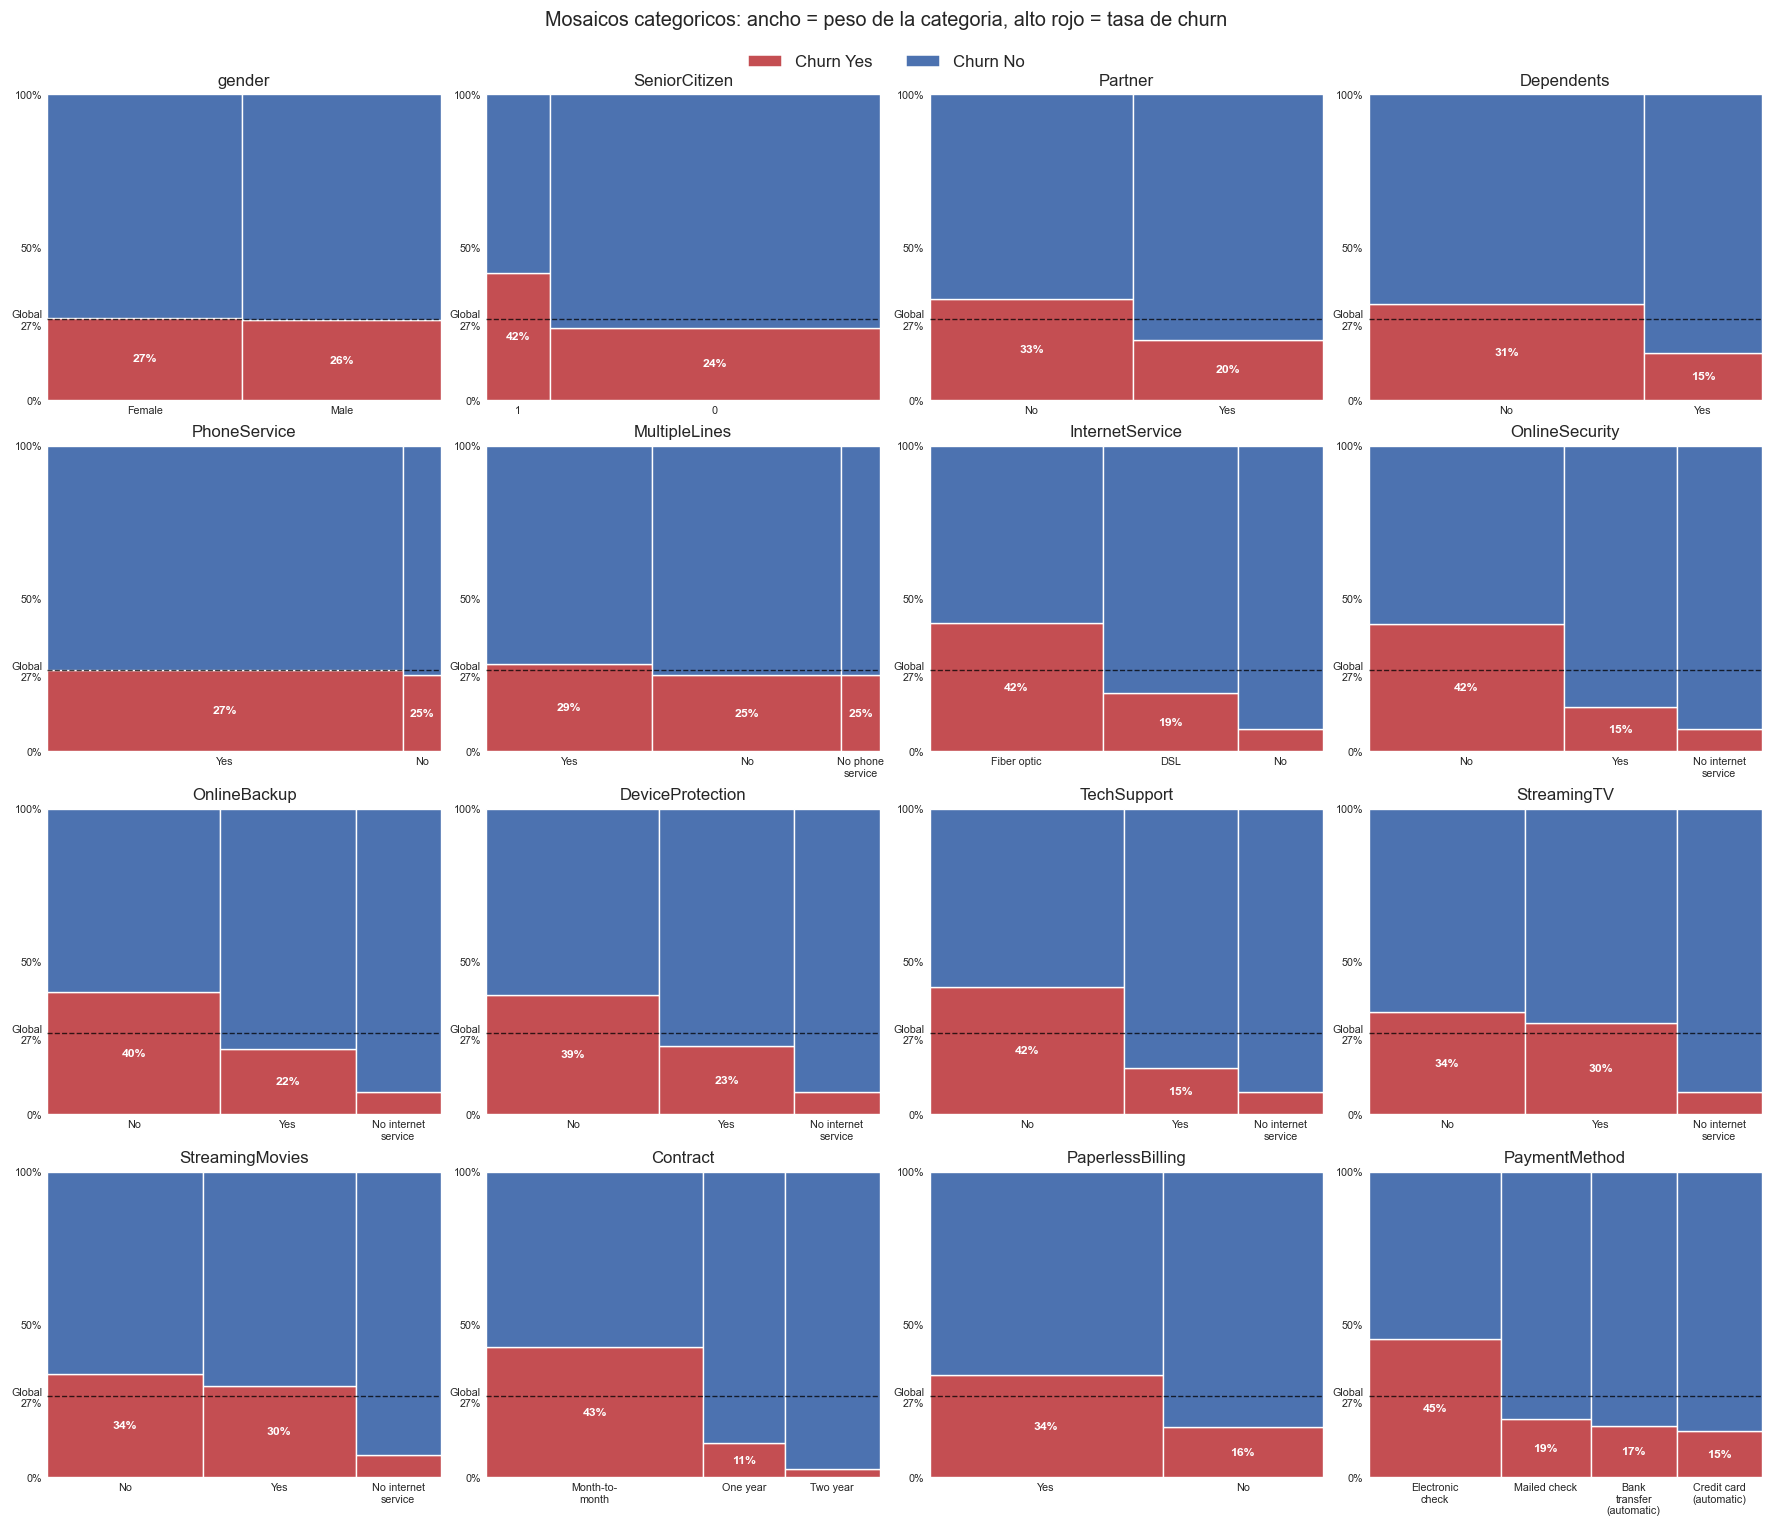

In [10]:
from matplotlib.patches import Patch, Rectangle
from textwrap import wrap

categoricas = [c for c in df.columns
               if c not in numericas + ["customerID", "Churn", "_churn"]]

churn_colors = {"No": "#4C72B0", "Yes": "#C44E52"}

def etiqueta_mosaico(valor, ancho=12):
    return "\n".join(wrap(str(valor), width=ancho, break_long_words=False))

def plot_mosaico_churn(ax, data, col):
    tabla = pd.crosstab(data[col].astype(str), data["Churn"])
    for target in ["Yes", "No"]:
        if target not in tabla.columns:
            tabla[target] = 0
    tabla = tabla[["Yes", "No"]]
    orden = (tabla["Yes"] / tabla.sum(axis=1)).sort_values(ascending=False).index
    tabla = tabla.loc[orden]

    total = tabla.to_numpy().sum()
    x0 = 0
    centros = []
    etiquetas = []
    for categoria, fila in tabla.iterrows():
        n_categoria = fila.sum()
        ancho = n_categoria / total
        y0 = 0
        for target in ["Yes", "No"]:
            alto = fila[target] / n_categoria if n_categoria else 0
            ax.add_patch(Rectangle((x0, y0), ancho, alto,
                                   facecolor=churn_colors[target],
                                   edgecolor="white", linewidth=0.9))
            if target == "Yes" and alto >= 0.08 and ancho >= 0.07:
                ax.text(x0 + ancho / 2, y0 + alto / 2, f"{alto:.0%}",
                        ha="center", va="center", fontsize=8, color="white",
                        fontweight="bold")
            y0 += alto
        centros.append(x0 + ancho / 2)
        etiquetas.append(etiqueta_mosaico(categoria))
        x0 += ancho

    ax.axhline(tasa_global, color="black", ls="--", lw=0.9, alpha=0.75)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(col, fontsize=11)
    ax.set_xticks(centros)
    ax.set_xticklabels(etiquetas, fontsize=7)
    ax.set_yticks([0, tasa_global, 0.5, 1])
    ax.set_yticklabels(["0%", f"Global\n{tasa_global:.0%}", "50%", "100%"], fontsize=7)
    ax.tick_params(axis="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

n_cols = 4
n_rows = int(np.ceil(len(categoricas) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.3 * n_rows), constrained_layout=True)
for ax, col in zip(axes.flat, categoricas):
    plot_mosaico_churn(ax, df, col)
for ax in axes.flat[len(categoricas):]:
    ax.axis("off")

handles = [Patch(facecolor=churn_colors["Yes"], label="Churn Yes"),
           Patch(facecolor=churn_colors["No"], label="Churn No")]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Mosaicos categoricos: ancho = peso de la categoria, alto rojo = tasa de churn", y=1.04, fontsize=13)
plt.show()

**Drivers más fuertes de churn:**
- En los mosaicos, el **ancho** muestra cuántos clientes hay en cada categoría y el **alto rojo** la proporción que churnea.
- `Contract`: mes a mes churnea **~43%** vs ~11% (1 año) y ~3% (2 años). Es el driver principal.
- `InternetService`: fibra óptica ~42% vs DSL ~19% -- posible problema de precio o calidad.
- `PaymentMethod`: cheque electrónico ~45%, muy por encima de los métodos automáticos.
- Servicios de protección/soporte (`OnlineSecurity`, `TechSupport`): no tenerlos casi
  **triplica** el churn (~42% vs ~15%).
- Variables demográficas (`gender`, `Partner`) casi no discriminan.

## 6. Asociaciones y redundancias

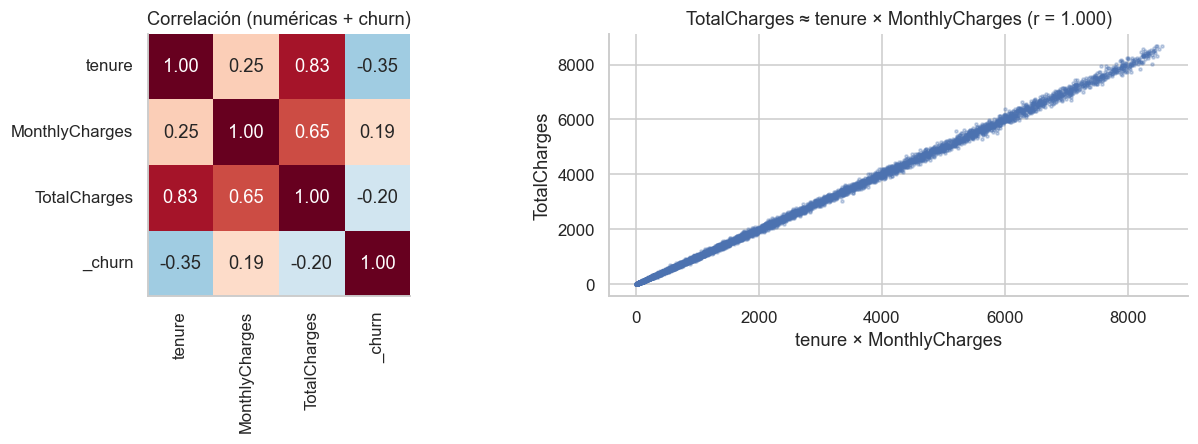

In [11]:
corr = df[numericas + ["_churn"]].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0],
            cbar=False, square=True)
axes[0].set_title("Correlación (numéricas + churn)")

axes[1].scatter(df["tenure"] * df["MonthlyCharges"], df["TotalCharges"], s=4, alpha=0.3)
axes[1].set_xlabel("tenure × MonthlyCharges")
axes[1].set_ylabel("TotalCharges")
axes[1].set_title(f"TotalCharges ≈ tenure × MonthlyCharges (r = "
                  f"{np.corrcoef(df['tenure'] * df['MonthlyCharges'], df['TotalCharges'])[0, 1]:.3f})")
sns.despine()
plt.tight_layout()
plt.show()

`TotalCharges` es prácticamente el producto `tenure × MonthlyCharges` (r ≈ 0,999):
es **redundante** y candidata a excluirse en los modelos lineales (colinealidad),
aunque los modelos de árboles la toleran sin problema.

## 7. Interacción clave: contrato × antigüedad

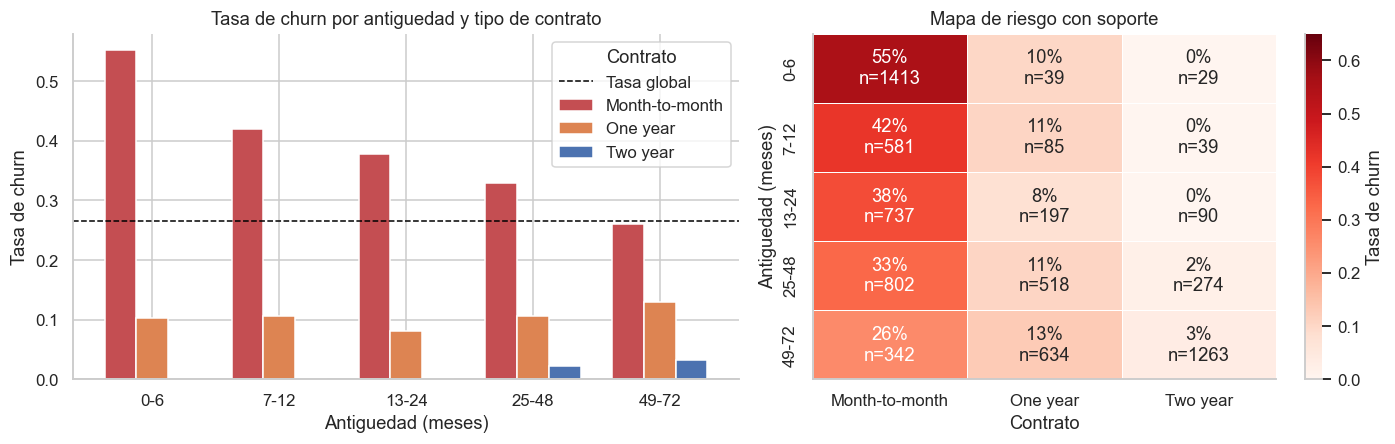

In [12]:
df["tenure_banda"] = pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 72],
                            labels=["0-6", "7-12", "13-24", "25-48", "49-72"])
pivot = df.pivot_table(index="tenure_banda", columns="Contract", values="_churn",
                       aggfunc="mean", observed=True)
soporte = df.pivot_table(index="tenure_banda", columns="Contract", values="_churn",
                         aggfunc="size", observed=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})
pivot.plot(kind="bar", ax=axes[0], color=["#C44E52", "#DD8452", "#4C72B0"], width=0.75)
axes[0].axhline(tasa_global, color="black", ls="--", lw=1, label="Tasa global")
axes[0].set_title("Tasa de churn por antiguedad y tipo de contrato")
axes[0].set_xlabel("Antiguedad (meses)")
axes[0].set_ylabel("Tasa de churn")
axes[0].legend(title="Contrato")
axes[0].tick_params(axis="x", rotation=0)

anotaciones = pivot.copy().astype(object)
for i in pivot.index:
    for j in pivot.columns:
        anotaciones.loc[i, j] = f"{pivot.loc[i, j]:.0%}\nn={int(soporte.loc[i, j])}"
sns.heatmap(pivot, annot=anotaciones, fmt="", cmap="Reds", vmin=0, vmax=0.65,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Tasa de churn"}, ax=axes[1])
axes[1].set_title("Mapa de riesgo con soporte")
axes[1].set_xlabel("Contrato")
axes[1].set_ylabel("Antiguedad (meses)")

sns.despine()
plt.tight_layout()
plt.show()

## 8. Vista previa de feature engineering: cantidad de servicios

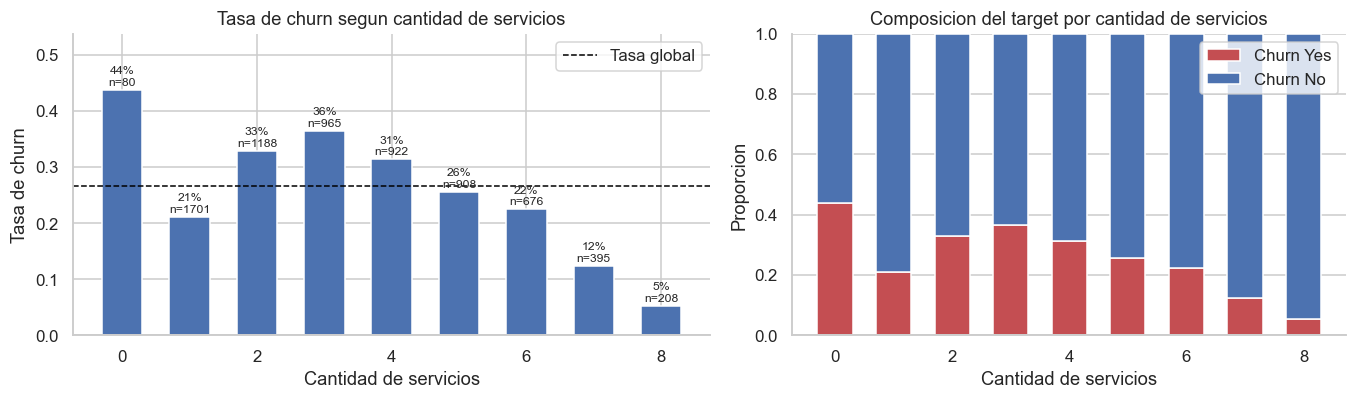

In [13]:
servicios = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
             "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df["n_servicios"] = (df[servicios] == "Yes").sum(axis=1)

tasas = df.groupby("n_servicios")["_churn"].agg(["mean", "size"])
composicion = pd.crosstab(df["n_servicios"], df["Churn"], normalize="index")[["Yes", "No"]]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), gridspec_kw={"width_ratios": [1.15, 1]})
axes[0].bar(tasas.index, tasas["mean"], color="#4C72B0", width=0.6)
axes[0].axhline(tasa_global, color="black", ls="--", lw=1, label="Tasa global")
for i, (t, n) in enumerate(zip(tasas["mean"], tasas["size"])):
    axes[0].text(tasas.index[i], t + 0.008, f"{t:.0%}\nn={n}", ha="center", fontsize=8)
axes[0].set_title("Tasa de churn segun cantidad de servicios")
axes[0].set_xlabel("Cantidad de servicios")
axes[0].set_ylabel("Tasa de churn")
axes[0].set_ylim(0, max(0.5, tasas["mean"].max() + 0.1))
axes[0].legend()

bottom = np.zeros(len(composicion))
for target in ["Yes", "No"]:
    axes[1].bar(composicion.index, composicion[target], bottom=bottom,
                color=churn_colors[target], width=0.6, label=f"Churn {target}")
    bottom += composicion[target].values
axes[1].set_title("Composicion del target por cantidad de servicios")
axes[1].set_xlabel("Cantidad de servicios")
axes[1].set_ylabel("Proporcion")
axes[1].set_ylim(0, 1)
axes[1].legend(loc="upper right")

sns.despine()
plt.tight_layout()
plt.show()

# limpiar columnas auxiliares del EDA
df = df.drop(columns=["_churn", "tenure_banda", "n_servicios"])

## 9. Conclusiones del EDA

1. **Dataset apto para el problema:** 7.043 clientes × 21 variables, sin duplicados,
   única limpieza necesaria: `TotalCharges` (11 clientes nuevos → imputar 0).
2. **Clases desbalanceadas** (26,5% churn) → PR-AUC como métrica de comparación,
   F2 para el umbral operativo, partición y CV **estratificadas**.
3. **Señal clara y consistente:** contrato mes a mes, poca antigüedad, fibra óptica,
   pago con cheque electrónico y falta de servicios de soporte/seguridad son los
   principales factores de riesgo. El problema parece bien modelable.
4. **Redundancia:** `TotalCharges` ≈ `tenure × MonthlyCharges` — atención a la
   colinealidad en modelos lineales.
5. **Ideas de feature engineering** para la fase de modelado: cantidad de servicios
   contratados, bandas de antigüedad, interacción contrato × antigüedad, ratio
   cargos mensuales / promedio del tipo de servicio.

**Limitaciones:** es una foto de un único mes (sin historia temporal), no hay datos de
uso, reclamos ni satisfacción, y no se conoce el costo real de una acción de retención.